<a href="https://colab.research.google.com/github/Marina4ij/FinalProject/blob/main/ProjectFLAML%26AutoGluon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 6.4 MB/s eta 0:00:00


In [1]:
!pip install flaml autogluon --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.4 MB/s eta 0:00

FLAML available
AutoGluon available
ЗАГРУЗКА ДАННЫХ
Всего страниц: 63856
Дней наблюдений: 730

EDA
Итоговый размер: 45263994 строк
Диапазон дат: 2018-01-01 00:00:00 - 2019-12-31 00:00:00

Топ-5 страниц по среднему трафику:
                                                              mean  \
Page                                                                 
Main_Page_en.wikipedia_all-access_all-agents          1.687435e+07   
Main_Page_en.wikipedia_mobile-web_all-agents          2.763755e+06   
Special:Search_en.wikipedia_all-access_all-agents     1.866894e+06   
Main_Page_en.wikipedia_all-access_spider              1.397412e+06   
Wikipedia:Hauptseite_de.wikipedia_desktop_all-agents  7.472705e+05   

                                                               std        min  \
Page                                                                            
Main_Page_en.wikipedia_all-access_all-agents          2.527575e+06  8701089.0   
Main_Page_en.wikipedia_mobile-web_all-agent

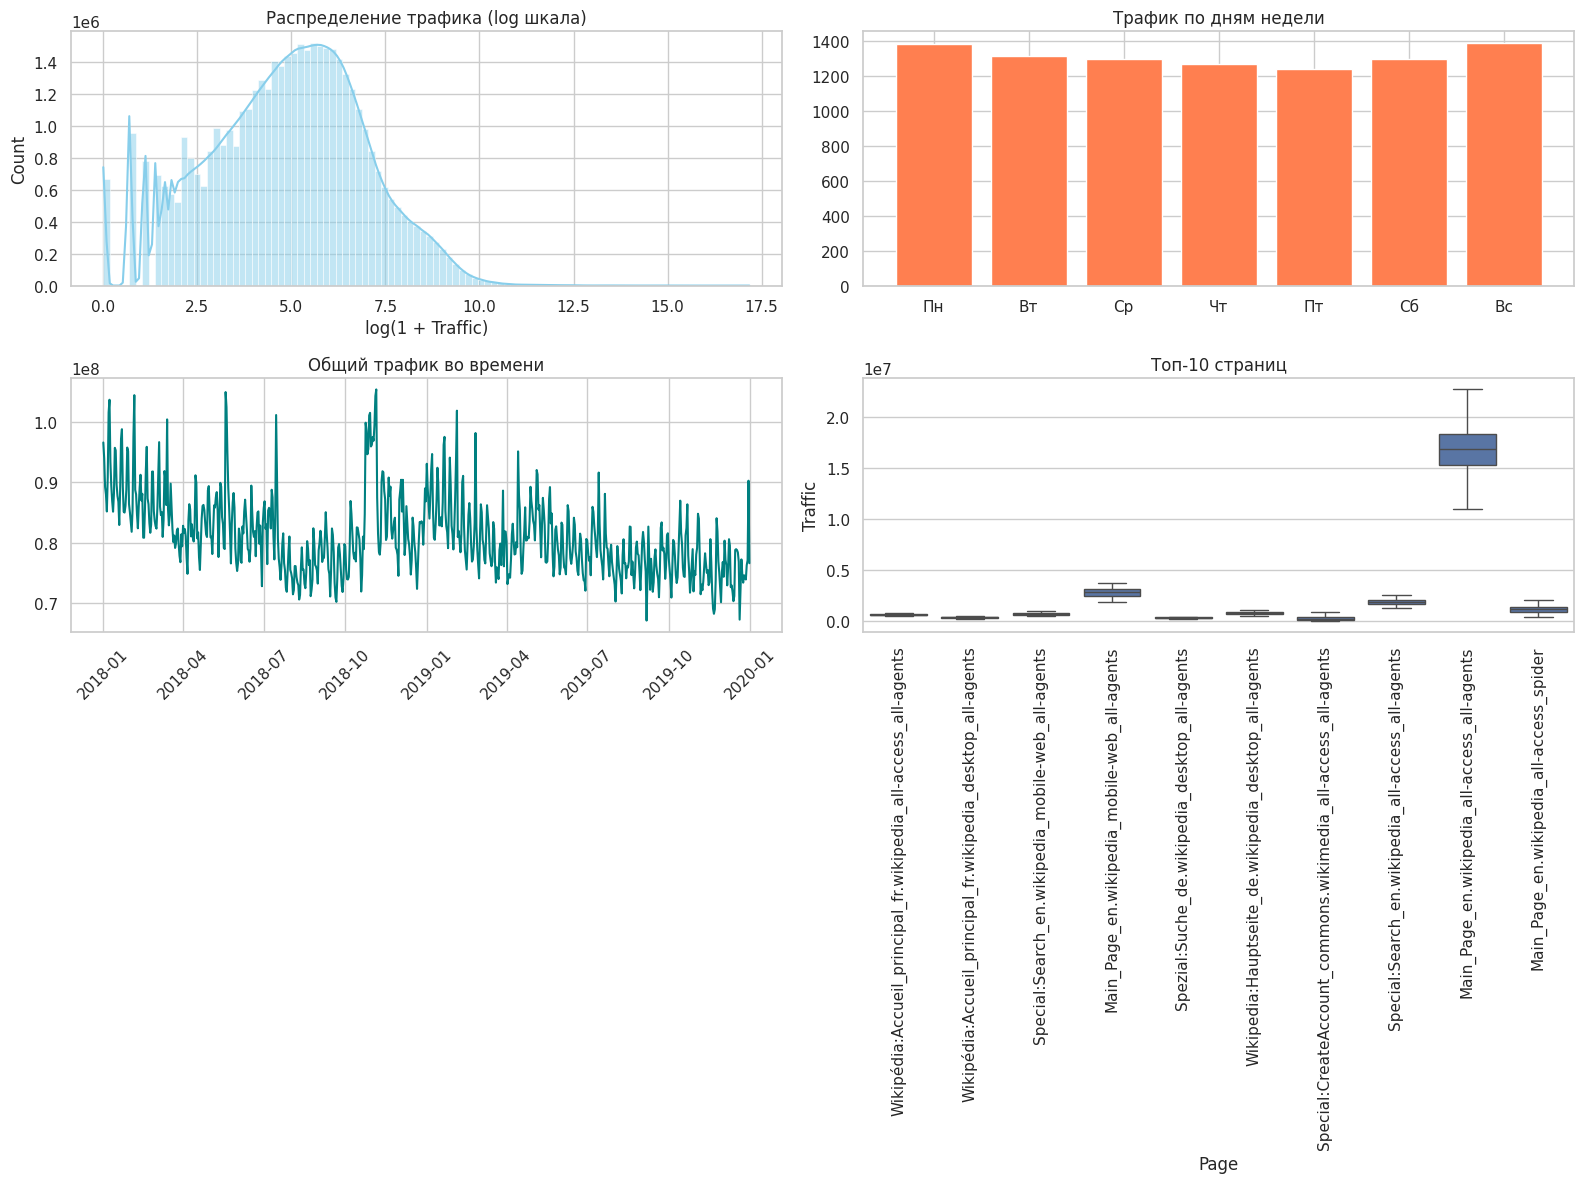


ПРЕДОБРАБОТКА
Выбрана страница: Main_Page_en.wikipedia_all-access_all-agents
Размер после feature engineering: (700, 14)
Train: 595, Test: 105

AUTOML ЧЕРЕЗ FLAML

Запуск FLAML (поиск лучшей модели за 2 минуты)...

Лучший estimator: extra_tree
Лучший RMSE на валидации: 1132292.06


Модель сохранена: flaml_best_model.pkl

AUTOML ЧЕРЕЗ AUTOGLUON

Запуск AutoGluon (поиск лучшей модели за 2 минуты)...

Leaderboard AutoGluon:
                 model     score_val    score_test
0      NeuralNetFastAI -1.076313e+06 -1.858731e+06
1       NeuralNetTorch -1.028714e+06 -1.911504e+06
2  WeightedEnsemble_L2 -9.259731e+05 -2.011050e+06
3        ExtraTreesMSE -1.059750e+06 -2.055285e+06
4      RandomForestMSE -1.115193e+06 -2.140530e+06
5             CatBoost -9.946072e+05 -2.148319e+06
6           LightGBMXT -9.404117e+05 -2.148901e+06
7              XGBoost -1.080558e+06 -2.438764e+06
8             LightGBM -1.021835e+06 -2.467259e+06
9        LightGBMLarge -1.130590e+06 -2.518519e+06

Лучшая модель AutoGluon: NeuralNetFastAI

МЕТРИКИ AUTOML МОДЕЛЕЙ:
FLAML_extra_tree                         | RMSE:    2100984 | MAE:    1399278 | R²:  0.491
AutoGluon_NeuralNetFastAI                | RMSE:    2011050 | MAE:    1336820 | R²:  0.533

Лучшая AutoML модель: AutoGluon_NeuralNetFastAI

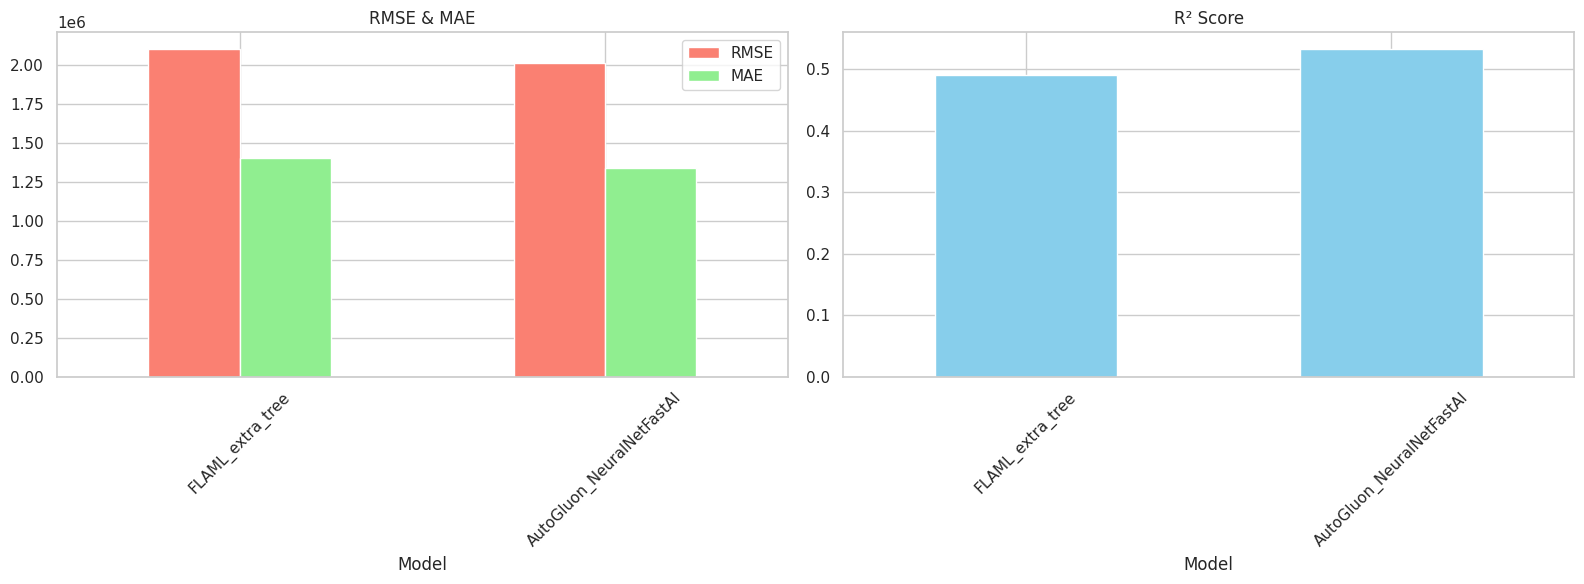

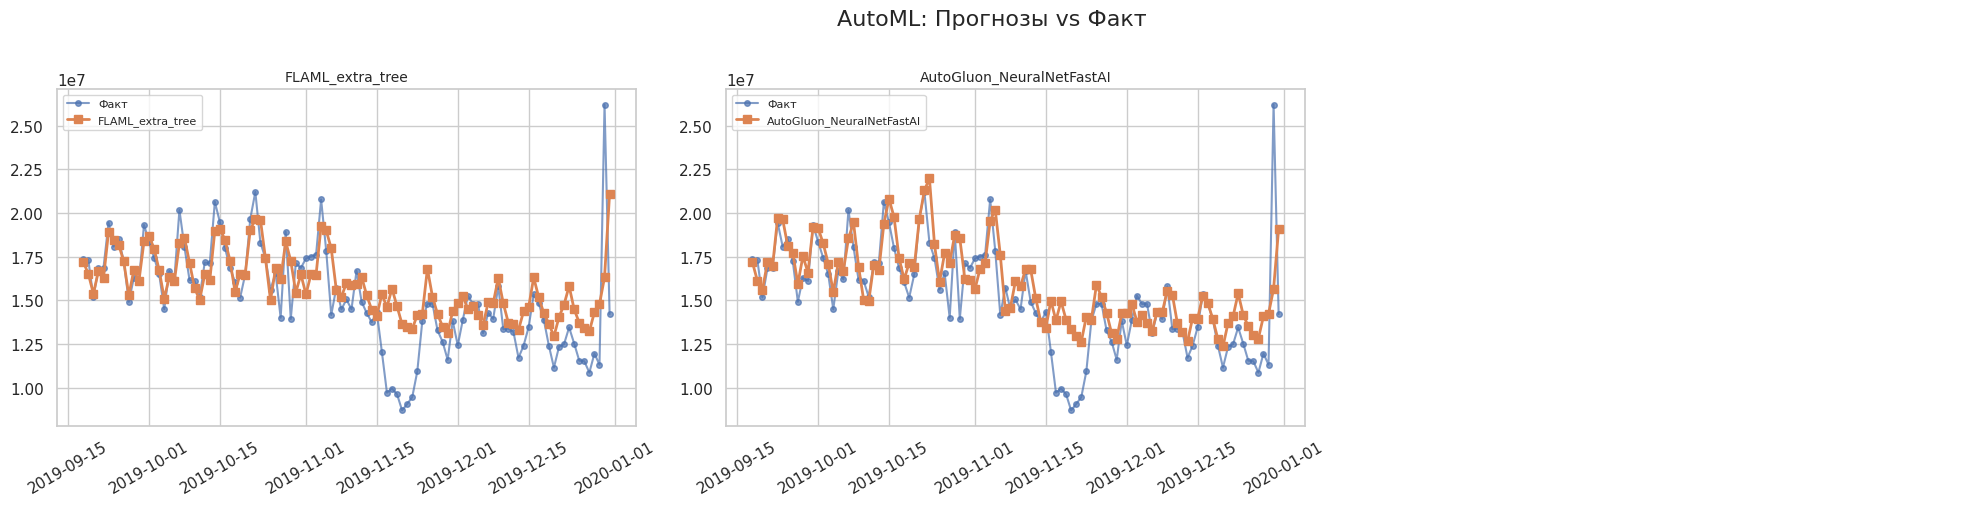

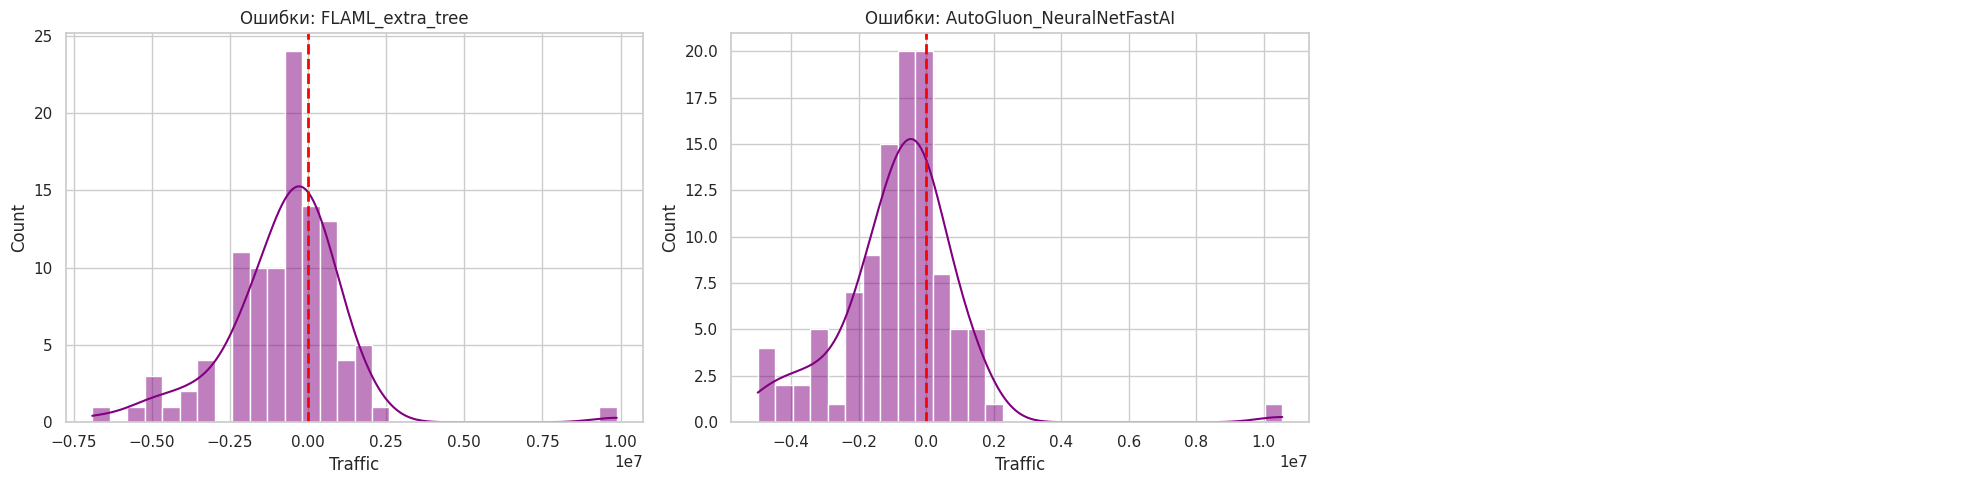

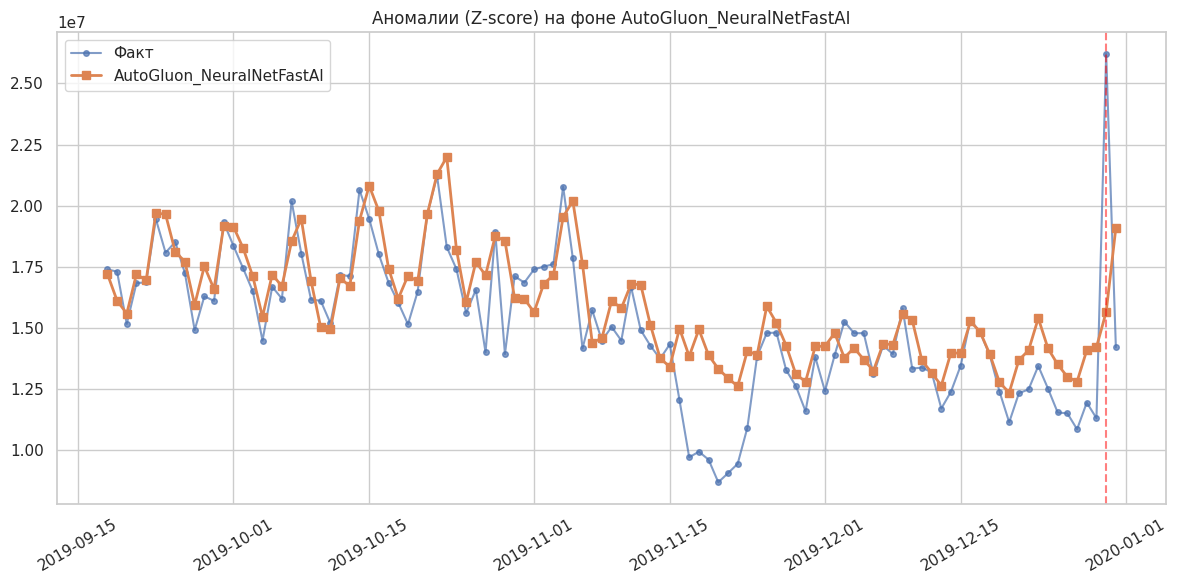

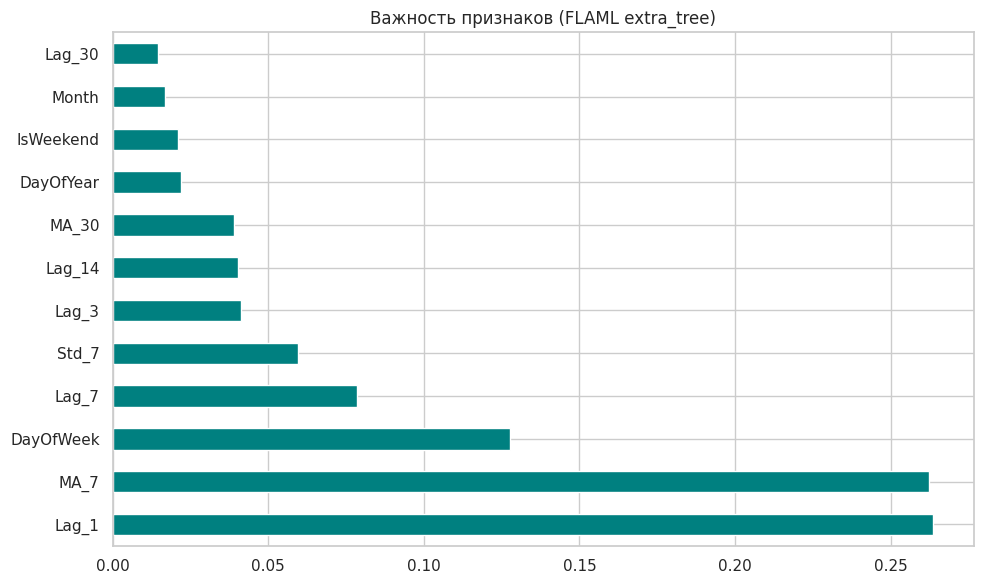


Все графики сохранены.
Проект AutoML завершён успешно!


In [3]:
# -*- coding: utf-8 -*-
"""
Wikipedia Web Traffic Analysis - AutoML VERSION (Python 3.12 compatible)
Используем FLAML + AutoGluon вместо PyCaret
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

# AutoML библиотеки
try:
    from flaml import AutoML as FLAML_AutoML
    FLAML_AVAILABLE = True
    print("FLAML available")
except ImportError:
    FLAML_AVAILABLE = False
    print("FLAML not installed. Install: pip install flaml")

try:
    from autogluon.tabular import TabularPredictor
    AUTOGLUON_AVAILABLE = True
    print("AutoGluon available")
except ImportError:
    AUTOGLUON_AVAILABLE = False
    print("AutoGluon not installed. Install: pip install autogluon")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================================
print("=" * 80)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

df = pd.read_csv("train/Wiki_Page_views.csv")
print(f"Всего страниц: {len(df)}")
print(f"Дней наблюдений: {len(df.columns) - 1}")

# ==========================================
# 2. EDA
# ==========================================
print("\n" + "=" * 80)
print("EDA")
print("=" * 80)

date_columns = [col for col in df.columns if col != "Page"]
df_long = df.melt(id_vars="Page", value_vars=date_columns, var_name="Date", value_name="Traffic")

def parse_date_column(date_series):
    try:
        return pd.to_datetime(date_series)
    except:
        pass
    date_str = date_series.astype(str)
    sample = date_str.iloc[0]
    if len(sample) == 8 and sample.isdigit():
        return pd.to_datetime(date_str, format="%Y%m%d")
    elif len(sample) == 10 and sample.isdigit():
        return pd.to_datetime(date_str.str[:8], format="%Y%m%d")
    elif " " in sample:
        return pd.to_datetime(date_str.str[:10], format="%Y-%m-%d")
    elif "-" in sample and len(sample) == 10:
        return pd.to_datetime(date_str, format="%Y-%m-%d")
    else:
        return pd.to_datetime(date_str, infer_datetime_format=True, errors='coerce')

df_long["Date"] = parse_date_column(df_long["Date"])
df_long = df_long.dropna(subset=["Date", "Traffic"])
df_long["Traffic"] = pd.to_numeric(df_long["Traffic"], errors="coerce")
df_long = df_long.dropna(subset=["Traffic"])

print(f"Итоговый размер: {len(df_long)} строк")
print(f"Диапазон дат: {df_long['Date'].min()} - {df_long['Date'].max()}")

# Статистика
stats = df_long.groupby("Page")["Traffic"].agg(["mean", "std", "min", "max"])
print("\nТоп-5 страниц по среднему трафику:")
print(stats.sort_values("mean", ascending=False).head())

# Визуализация EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

traffic_log = np.log1p(df_long["Traffic"])
sns.histplot(traffic_log, bins=100, kde=True, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Распределение трафика (log шкала)")
axes[0,0].set_xlabel("log(1 + Traffic)")

df_long["DayOfWeek"] = df_long["Date"].dt.dayofweek
weekly = df_long.groupby("DayOfWeek")["Traffic"].mean()
days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
axes[0,1].bar(days, weekly, color="coral")
axes[0,1].set_title("Трафик по дням недели")

daily_agg = df_long.groupby("Date")["Traffic"].sum()
axes[1,0].plot(daily_agg.index, daily_agg.values, linewidth=1.5, color="teal")
axes[1,0].set_title("Общий трафик во времени")
axes[1,0].tick_params(axis='x', rotation=45)

top_pages = stats.sort_values("mean", ascending=False).index[:10]
df_top = df_long[df_long["Page"].isin(top_pages)]
sns.boxplot(data=df_top, x="Page", y="Traffic", ax=axes[1,1], showfliers=False)
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].set_title("Топ-10 страниц")

plt.tight_layout()
plt.savefig("1_eda_plots.png", dpi=150)
plt.show()

# ==========================================
# 3. ПРЕДОБРАБОТКА
# ==========================================
print("\n" + "=" * 80)
print("ПРЕДОБРАБОТКА")
print("=" * 80)

page_stats = df_long.groupby("Page")["Traffic"].mean()
target_page = page_stats.idxmax()
print(f"Выбрана страница: {target_page}")

ts_data = df_long[df_long["Page"] == target_page].copy()
ts_data = ts_data[["Date", "Traffic"]].copy()
ts_data.sort_values("Date", inplace=True)
ts_data.set_index("Date", inplace=True)
ts_data["Traffic"] = ts_data["Traffic"].interpolate(method="linear").bfill().ffill()

# Feature Engineering
ts_data["DayOfWeek"] = ts_data.index.dayofweek
ts_data["DayOfMonth"] = ts_data.index.day
ts_data["Month"] = ts_data.index.month
ts_data["DayOfYear"] = ts_data.index.dayofyear
ts_data["IsWeekend"] = (ts_data["DayOfWeek"] >= 5).astype(int)

for lag in [1, 3, 7, 14, 30]:
    ts_data[f"Lag_{lag}"] = ts_data["Traffic"].shift(lag)

ts_data["MA_7"] = ts_data["Traffic"].rolling(window=7).mean()
ts_data["MA_30"] = ts_data["Traffic"].rolling(window=30).mean()
ts_data["Std_7"] = ts_data["Traffic"].rolling(window=7).std()
ts_data.dropna(inplace=True)

print(f"Размер после feature engineering: {ts_data.shape}")

# Разделение
split_idx = int(len(ts_data) * 0.85)
train = ts_data.iloc[:split_idx]
test = ts_data.iloc[split_idx:]

X_train = train.drop("Traffic", axis=1)
y_train = train["Traffic"]
X_test = test.drop("Traffic", axis=1)
y_test = test["Traffic"]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# ==========================================
# 4. AUTOML ЧЕРЕЗ FLAML
# ==========================================
print("\n" + "=" * 80)
print("AUTOML ЧЕРЕЗ FLAML")
print("=" * 80)

results = {}

if FLAML_AVAILABLE:
    print("\nЗапуск FLAML (поиск лучшей модели за 2 минуты)...")

    flaml_automl = FLAML_AutoML()
    flaml_settings = {
        "time_budget": 120,
        "metric": 'rmse',
        "task": 'regression',
        "estimator_list": ['lgbm', 'xgboost', 'rf', 'extra_tree'],
        "log_file_name": 'flaml.log',
        "eval_method": 'cv',
        "n_splits": 3,
        "hpo_method": 'auto',
        "verbose": 0
    }

    flaml_automl.fit(X_train=X_train, y_train=y_train, **flaml_settings)

    print(f"\nЛучший estimator: {flaml_automl.best_estimator}")
    print(f"Лучший RMSE на валидации: {flaml_automl.best_loss:.2f}")

    pred_flaml = flaml_automl.predict(X_test)
    results[f"FLAML_{flaml_automl.best_estimator}"] = pred_flaml

    # Сохранение
    try:
        import pickle
        with open('flaml_best_model.pkl', 'wb') as f:
            pickle.dump(flaml_automl, f)
        print("Модель сохранена: flaml_best_model.pkl")
    except Exception as e:
        print(f"Не удалось сохранить: {e}")
else:
    print("FLAML недоступен")

# ==========================================
# 5. AUTOML ЧЕРЕЗ AUTOGLUON
# ==========================================
print("\n" + "=" * 80)
print("AUTOML ЧЕРЕЗ AUTOGLUON")
print("=" * 80)

if AUTOGLUON_AVAILABLE:
    print("\nЗапуск AutoGluon (поиск лучшей модели за 2 минуты)...")

    # AutoGluon требует DataFrame с целевой колонкой
    train_df = X_train.copy()
    train_df["Traffic"] = y_train
    test_df = X_test.copy()
    test_df["Traffic"] = y_test

    try:
        predictor = TabularPredictor(
            label="Traffic",
            problem_type='regression',
            eval_metric='rmse',
            path='autogluon_models'
        ).fit(
            train_data=train_df,
            time_limit=120,
            presets='medium_quality',
            verbosity=0
        )

        # Прогноз
        pred_ag = predictor.predict(test_df.drop("Traffic", axis=1))

        # Получение leaderboard
        leaderboard = predictor.leaderboard(test_df)
        print("\nLeaderboard AutoGluon:")
        print(leaderboard[['model', 'score_val', 'score_test']].head(10))

        best_model_name = leaderboard.iloc[0]['model']
        results[f"AutoGluon_{best_model_name}"] = pred_ag.values

        print(f"\nЛучшая модель AutoGluon: {best_model_name}")

    except Exception as e:
        print(f"AutoGluon error: {e}")
else:
    print("AutoGluon недоступен")

# ==========================================
# 6. ОЦЕНКА КАЧЕСТВА
# ==========================================
print("\n" + "=" * 80)
print("МЕТРИКИ AUTOML МОДЕЛЕЙ:")
print("=" * 80)

if not results:
    print("Нет обученных AutoML моделей!")
else:
    metrics = []
    for name, preds in results.items():
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        metrics.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
        print(f"{name:40} | RMSE: {rmse:10.0f} | MAE: {mae:10.0f} | R²: {r2:6.3f}")

    metrics_df = pd.DataFrame(metrics).set_index("Model")
    best_model_name = metrics_df["RMSE"].idxmin()
    print(f"\nЛучшая AutoML модель: {best_model_name}")

    # ==========================================
    # 7. ПОИСК АНОМАЛИЙ
    # ==========================================
    print("\n" + "=" * 80)
    print("ПОИСК АНОМАЛИЙ")
    print("=" * 80)

    residuals = y_test - results[best_model_name]

    iso = IsolationForest(contamination=0.05, random_state=42)
    iso_pred = iso.fit_predict(X_test)
    anomalies_iso = X_test[iso_pred == -1]

    z_scores = np.abs((residuals - residuals.mean()) / residuals.std())
    anomalies_z = test.index[z_scores > 3]

    Q1, Q3 = residuals.quantile(0.25), residuals.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
    anomalies_iqr = test.index[(residuals < lower) | (residuals > upper)]

    print(f"Isolation Forest: {len(anomalies_iso)} аномалий")
    print(f"Z-score (|Z|>3): {len(anomalies_z)} аномалий")
    print(f"IQR метод: {len(anomalies_iqr)} аномалий")

    # ==========================================
    # 8. ВИЗУАЛИЗАЦИЯ
    # ==========================================
    print("\n" + "=" * 80)
    print("ГЕНЕРАЦИЯ ГРАФИКОВ")
    print("=" * 80)

    # 1. Метрики
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    metrics_df[["RMSE", "MAE"]].plot(kind="bar", ax=ax[0], color=["salmon", "lightgreen"])
    ax[0].set_title("RMSE & MAE")
    ax[0].tick_params(axis='x', rotation=45)
    metrics_df["R²"].plot(kind="bar", ax=ax[1], color="skyblue")
    ax[1].set_title("R² Score")
    ax[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig("4_metrics_comparison_automl.png", dpi=150)
    plt.show()

    # 2. Прогнозы
    n_models = len(results)
    n_rows = (n_models + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5*n_rows))
    axes_flat = axes.flatten()

    for i, (name, preds) in enumerate(results.items()):
        axes_flat[i].plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
        axes_flat[i].plot(y_test.index, preds, "s-", label=name, linewidth=2)
        axes_flat[i].set_title(name, fontsize=10)
        axes_flat[i].legend(fontsize=8)
        axes_flat[i].tick_params(axis='x', rotation=30)

    for i in range(n_models, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.suptitle("AutoML: Прогнозы vs Факт", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig("2_forecast_plots_automl.png", dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Ошибки
    fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5*n_rows))
    axes_flat = axes.flatten()

    for i, (name, preds) in enumerate(results.items()):
        err = y_test - preds
        sns.histplot(err, bins=30, kde=True, ax=axes_flat[i], color="purple")
        axes_flat[i].axvline(0, color="red", linestyle="--", linewidth=2)
        axes_flat[i].set_title(f"Ошибки: {name}")

    for i in range(n_models, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout()
    plt.savefig("3_residuals_plots_automl.png", dpi=150)
    plt.show()

    # 4. Аномалии
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
    plt.plot(y_test.index, results[best_model_name], "s-", label=f"{best_model_name}", linewidth=2)
    for date in anomalies_z:
        plt.axvline(date, color="red", linestyle="--", alpha=0.5)
    plt.title(f"Аномалии (Z-score) на фоне {best_model_name}")
    plt.legend()
    plt.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig("6_anomaly_detection_automl.png", dpi=150)
    plt.show()

    # 5. Важность признаков (если есть)
    if FLAML_AVAILABLE and 'flaml_automl' in locals():
        try:
            importances = flaml_automl.feature_importances_
            feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
            plt.figure(figsize=(10, 6))
            feat_imp.head(12).plot(kind="barh", color="teal")
            plt.title(f"Важность признаков (FLAML {flaml_automl.best_estimator})")
            plt.tight_layout()
            plt.savefig("5_feature_importance_automl.png", dpi=150)
            plt.show()
        except Exception as e:
            print(f"Feature importance skipped: {e}")

print("\n" + "=" * 80)
print("Все графики сохранены.")
print("Проект AutoML завершён успешно!")
print("=" * 80)

FLAML: available
AutoGluon: available
ЗАГРУЗКА ДАННЫХ
Загружено: 63856 страниц, 730 дней

Парсинг дат формата YYYYMMDDHH...
Валидных дат: 730 из 730
Диапазон: 2018-01-01 00:00:00 - 2019-12-31 00:00:00

EDA (ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ)
Итоговый размер: 45,263,994 наблюдений
Диапазон дат: 2018-01-01 00:00:00 - 2019-12-31 00:00:00
Всего страниц: 63856

Топ-5 страниц по среднему трафику:
                                                              mean  \
Page                                                                 
Main_Page_en.wikipedia_all-access_all-agents          1.687435e+07   
Main_Page_en.wikipedia_mobile-web_all-agents          2.763755e+06   
Special:Search_en.wikipedia_all-access_all-agents     1.866894e+06   
Main_Page_en.wikipedia_all-access_spider              1.397412e+06   
Wikipedia:Hauptseite_de.wikipedia_desktop_all-agents  7.472705e+05   

                                                               std        min  \
Page                                       

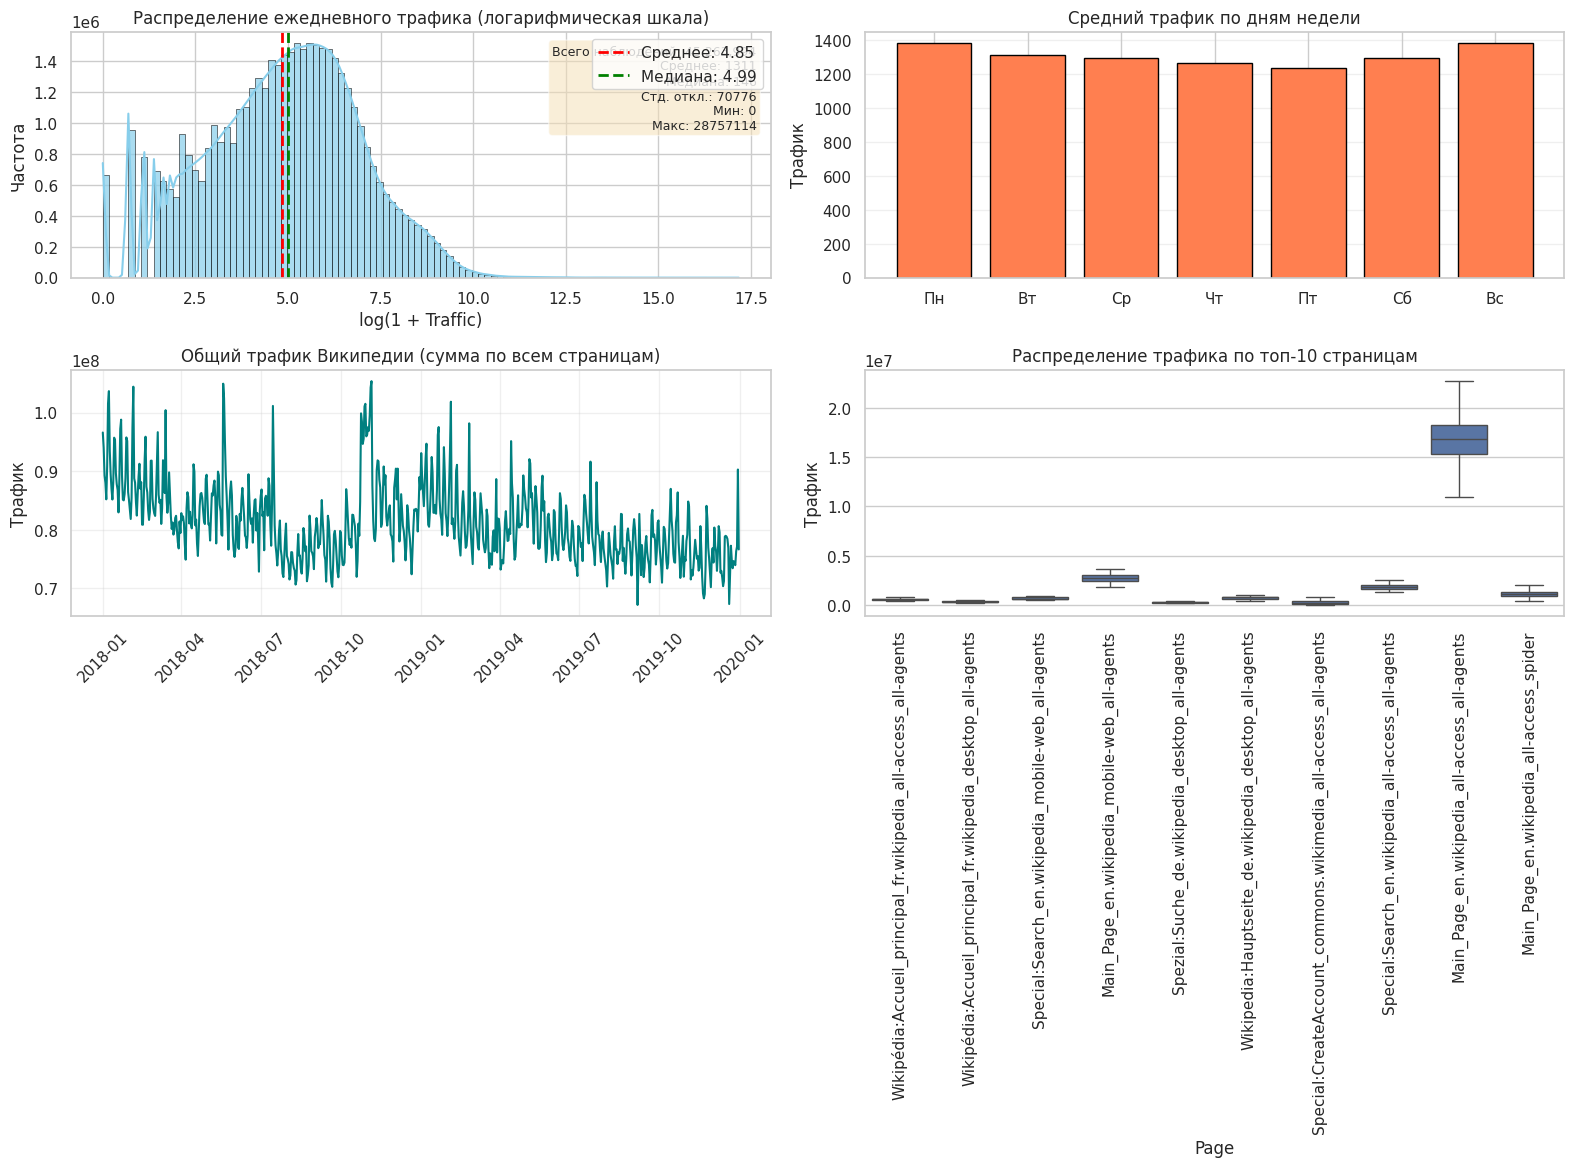


ПРЕДОБРАБОТКА ДАННЫХ
Выбрана страница: Main_Page_en.wikipedia_all-access_all-agents
Средний трафик: 16874347
Размер после feature engineering: (700, 14)
Признаков: 13
Train: 595 obs, Test: 105 obs

БАЗОВЫЕ МОДЕЛИ (для сравнения с AutoML)
[1/3] Linear Regression...
[2/3] Ridge Regression...
[3/3] Random Forest...

AUTOML ЧЕРЕЗ FLAML

Запуск FLAML AutoML (поиск лучшей модели за 3 минуты)...
FLAML тестирует: LightGBM, XGBoost, Random Forest, Extra Trees, CatBoost
Автоматический подбор гиперпараметров через Bayesian Optimization

Результаты FLAML:
  Лучший estimator: extra_tree
  Лучший RMSE на валидации (CV): 1132292.06
  Время обучения: 2.13 сек

Топ-5 конфигураций FLAML:
  lgbm: {'n_estimators': 339, 'num_leaves': 11, 'min_child_samples': 2, 'learning_rate': 0.0709077960539148, 'log_max_bin': 10, 'colsample_bytree': 0.9580052284932868, 'reg_alpha': 0.0009765625, 'reg_lambda': 4.856517064056754}
  xgboost: {'n_estimators': 14, 'max_leaves': 6, 'min_child_weight': 5.651307320963654, 'lea


Модель сохранена: flaml_best_model.pkl

AUTOML ЧЕРЕЗ AUTOGLUON

Запуск AutoGluon (поиск лучшей модели за 2 минуты)...

Leaderboard AutoGluon (топ-5):
                 model     score_val
0      NeuralNetFastAI -1.076313e+06
1       NeuralNetTorch -1.028714e+06
2  WeightedEnsemble_L2 -9.259731e+05
3        ExtraTreesMSE -1.059750e+06
4      RandomForestMSE -1.115193e+06

Лучшая модель AutoGluon: NeuralNetFastAI

МЕТРИКИ ВСЕХ МОДЕЛЕЙ (Базовые + AutoML)
Linear Regression                   | RMSE:    1680438 | MAE:    1063714 | R2:  0.674
Ridge                               | RMSE:    1697903 | MAE:    1053426 | R2:  0.667
Random Forest                       | RMSE:    2124293 | MAE:    1397725 | R2:  0.479
FLAML_extra_tree                    | RMSE:    2100984 | MAE:    1399278 | R2:  0.491
AutoGluon_NeuralNetFastAI           | RMSE:    2011050 | MAE:    1336820 | R2:  0.533

Лучшая модель (все): Linear Regression
Лучшая AutoML модель: AutoGluon_NeuralNetFastAI

Улучшение AutoML над лучш

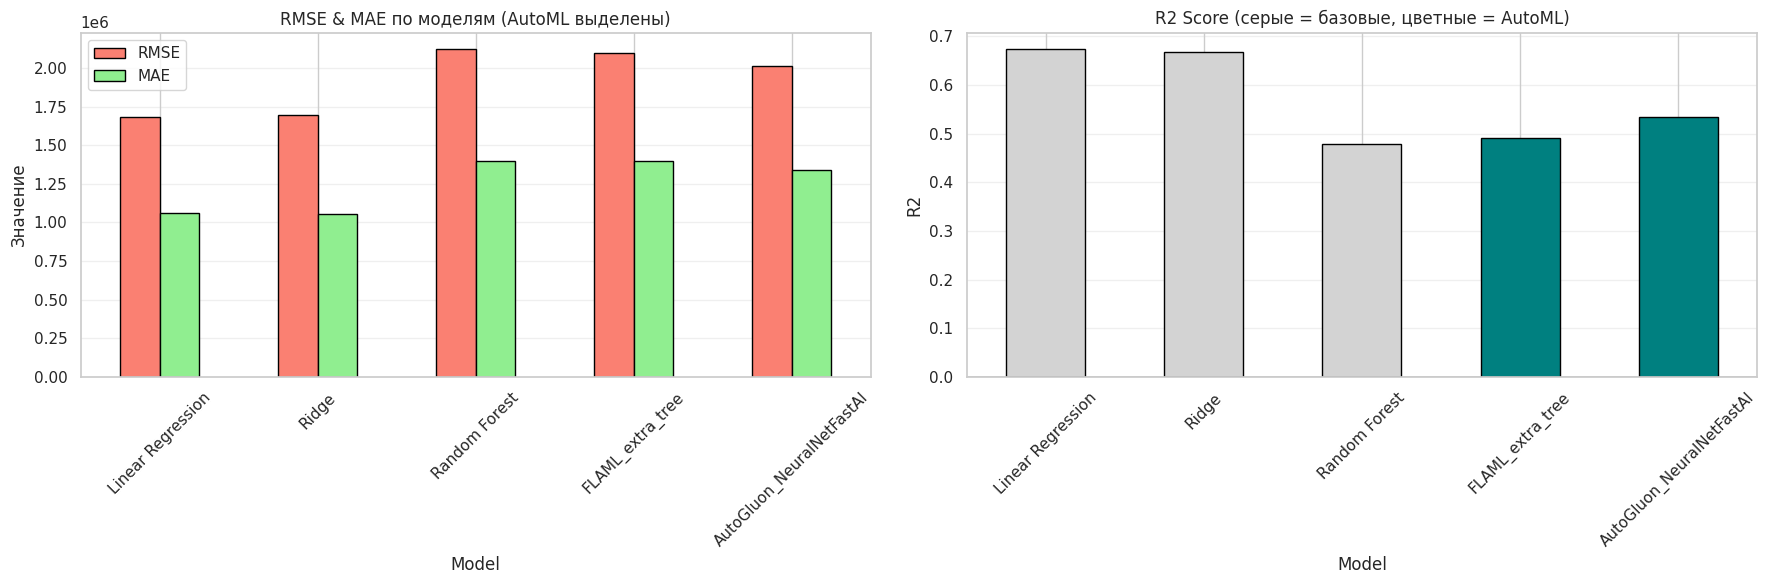

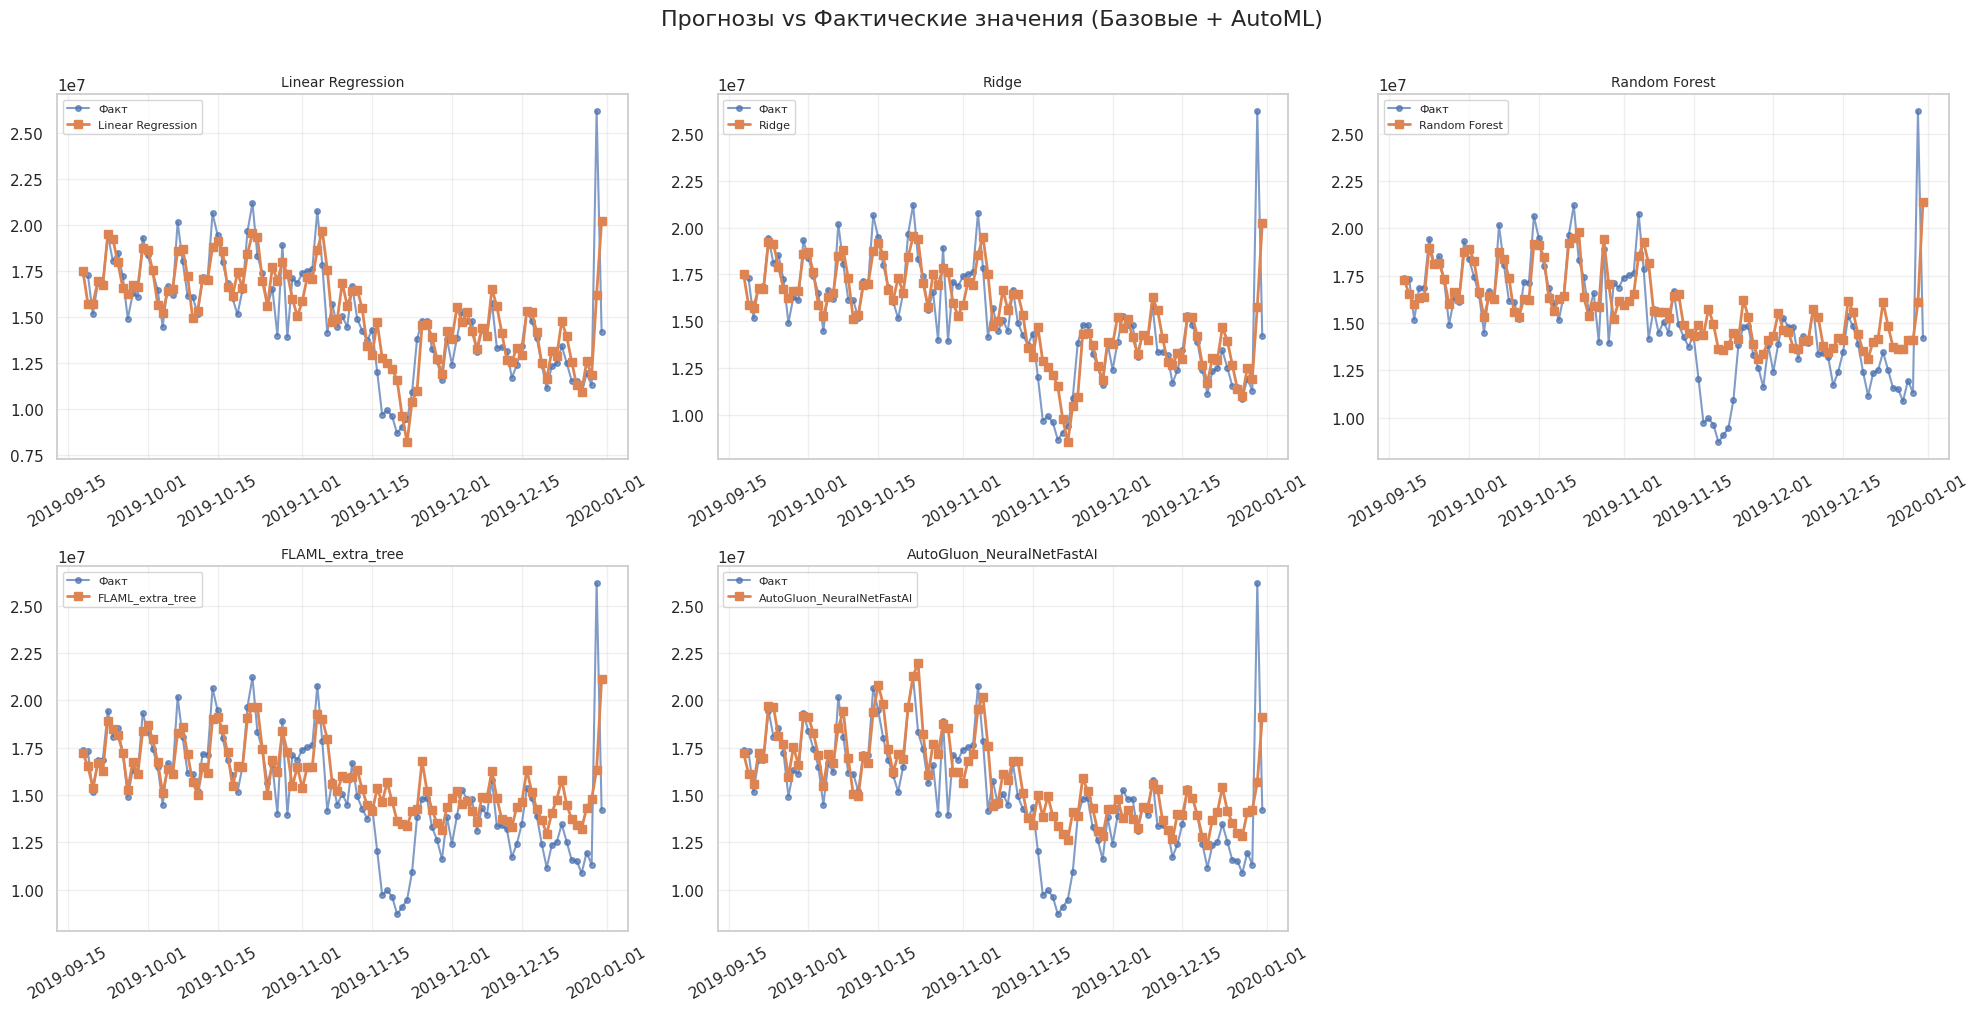

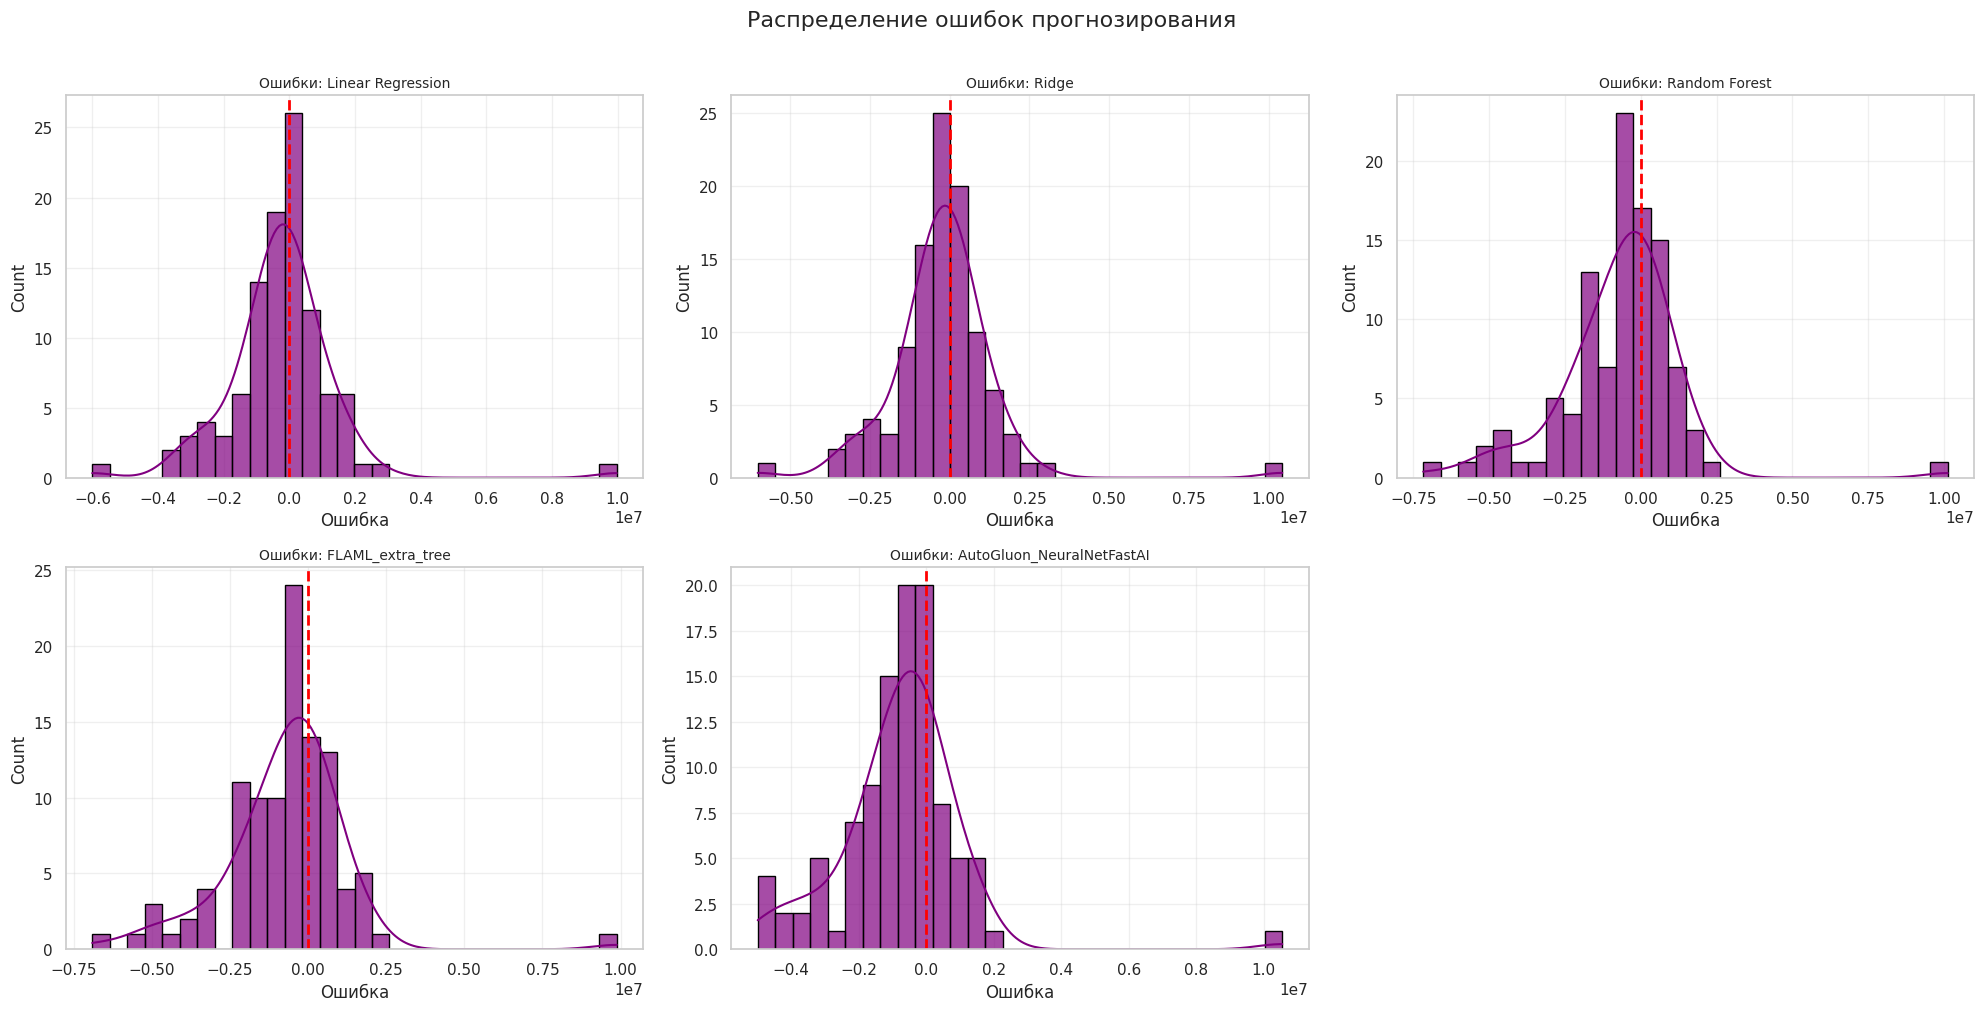

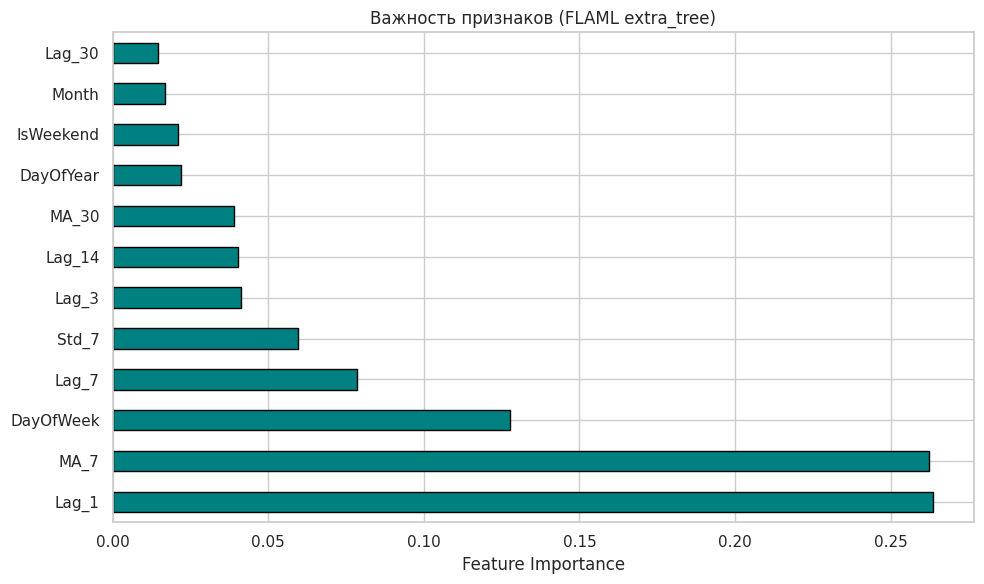

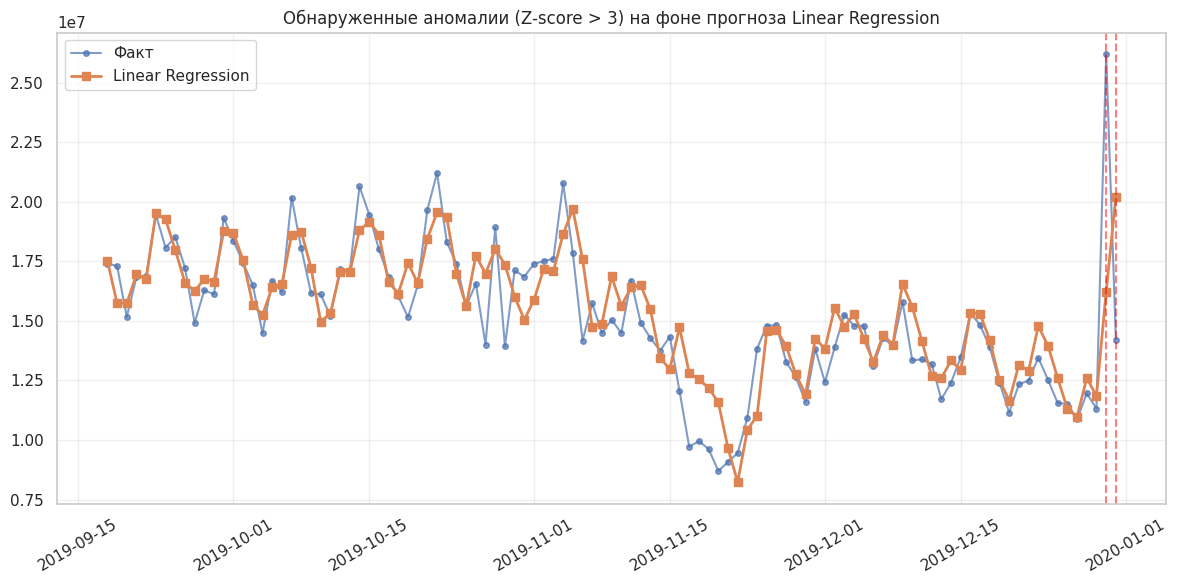

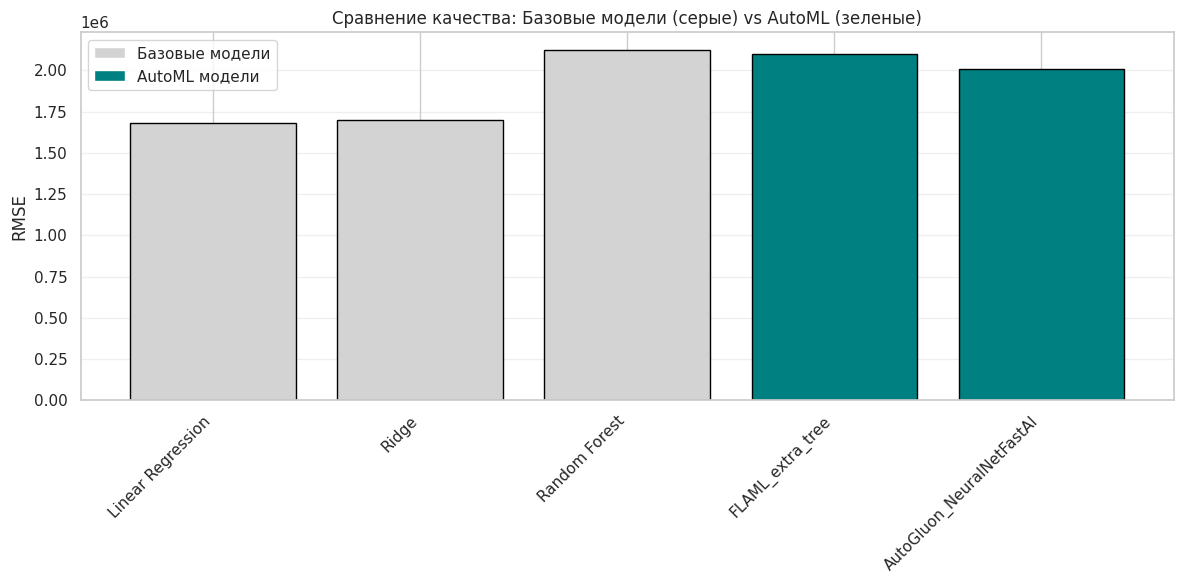


ИТОГОВЫЙ ОТЧЕТ

Датасет:
  - Страниц: 63,856
  - Дней: 730
  - Период: 2018-01-01 - 2019-12-31
  - Анализ страницы: Main_Page_en.wikipedia_all-access_all-agents

Модели обучены:
  - Базовые: Linear Regression, Ridge, Random Forest
  - AutoML (FLAML): extra_tree
  - AutoML (AutoGluon): NeuralNetFastAI

Лучшая модель: Linear Regression
  - RMSE: 1680438
  - MAE: 1063714
  - R2: 0.674

AutoML результат:
  - Лучшая AutoML модель: AutoGluon_NeuralNetFastAI
  - Улучшение над базовыми: -19.67%

Аномалии:
  - Isolation Forest: 6
  - Z-score: 2
  - IQR: 2

Все графики сохранены в директории:
  1_eda_plots.png
  2_metrics_comparison_automl.png
  3_forecast_plots_automl.png
  4_residuals_plots_automl.png
  5_feature_importance.png
  6_anomaly_detection_automl.png
  7_automl_vs_baseline.png

Проект AutoML завершён успешно!


In [4]:
# -*- coding: utf-8 -*-
"""
Wikipedia Web Traffic Analysis - AutoML VERSION
Python 3.12 compatible (FLAML + опционально AutoGluon)
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import IsolationForest

# AutoML библиотеки
try:
    from flaml import AutoML as FLAML_AutoML
    FLAML_AVAILABLE = True
    print("FLAML: available")
except ImportError:
    FLAML_AVAILABLE = False
    print("FLAML: NOT installed. Run: pip install flaml")

try:
    from autogluon.tabular import TabularPredictor
    AUTOGLUON_AVAILABLE = True
    print("AutoGluon: available")
except ImportError:
    AUTOGLUON_AVAILABLE = False
    print("AutoGluon: NOT installed (optional)")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================================
print("=" * 80)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

df = pd.read_csv("train/Wiki_Page_views.csv")
print(f"Загружено: {df.shape[0]} страниц, {df.shape[1]-1} дней")

# ==========================================
# 2. ПРАВИЛЬНЫЙ ПАРСИНГ ДАТ (формат YYYYMMDDHH)
# ==========================================
print("\nПарсинг дат формата YYYYMMDDHH...")

date_col_names = df.columns[1:]
# Обрезаем последние 2 символа (часы "00") и парсим
dates_parsed = pd.to_datetime(date_col_names.str[:8], format='%Y%m%d', errors='coerce')
valid_mask = dates_parsed.notna()

print(f"Валидных дат: {valid_mask.sum()} из {len(date_col_names)}")
print(f"Диапазон: {dates_parsed[valid_mask].min()} - {dates_parsed[valid_mask].max()}")

# Фильтруем только валидные колонки
df_filtered = df.iloc[:, [0] + list(np.where(valid_mask)[0] + 1)].copy()
df_filtered.columns = ['Page'] + [d.strftime('%Y-%m-%d') for d in dates_parsed[valid_mask]]

# ==========================================
# 3. EDA
# ==========================================
print("\n" + "=" * 80)
print("EDA (ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ)")
print("=" * 80)

df_long = df_filtered.melt(id_vars="Page", var_name="Date", value_name="Traffic")
df_long["Date"] = pd.to_datetime(df_long["Date"])
df_long["Traffic"] = pd.to_numeric(df_long["Traffic"], errors="coerce")
df_long = df_long.dropna(subset=["Date", "Traffic"])

print(f"Итоговый размер: {len(df_long):,} наблюдений")
print(f"Диапазон дат: {df_long['Date'].min()} - {df_long['Date'].max()}")

# Статистика по страницам
stats = df_long.groupby("Page")["Traffic"].agg(["mean", "std", "min", "max", "count"])
print(f"Всего страниц: {len(stats)}")
print("\nТоп-5 страниц по среднему трафику:")
print(stats.sort_values("mean", ascending=False).head())

# Визуализация EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение трафика (log шкала)
traffic_log = np.log1p(df_long["Traffic"])
sns.histplot(traffic_log, bins=100, kde=True, ax=axes[0,0], color="skyblue", edgecolor='black', alpha=0.7)
axes[0,0].set_title("Распределение ежедневного трафика (логарифмическая шкала)")
axes[0,0].set_xlabel("log(1 + Traffic)")
axes[0,0].set_ylabel("Частота")
mean_log = traffic_log.mean()
median_log = traffic_log.median()
axes[0,0].axvline(mean_log, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_log:.2f}')
axes[0,0].axvline(median_log, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_log:.2f}')
axes[0,0].legend()

stats_text = f"Всего наблюдений: {len(df_long):,}\n"
stats_text += f"Среднее: {df_long['Traffic'].mean():.0f}\n"
stats_text += f"Медиана: {df_long['Traffic'].median():.0f}\n"
stats_text += f"Стд. откл.: {df_long['Traffic'].std():.0f}\n"
stats_text += f"Мин: {df_long['Traffic'].min():.0f}\n"
stats_text += f"Макс: {df_long['Traffic'].max():.0f}"
axes[0,0].text(0.98, 0.95, stats_text, transform=axes[0,0].transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

# 2. Недельная сезонность
df_long["DayOfWeek"] = df_long["Date"].dt.dayofweek
weekly = df_long.groupby("DayOfWeek")["Traffic"].mean()
days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
axes[0,1].bar(days, weekly, color="coral", edgecolor='black')
axes[0,1].set_title("Средний трафик по дням недели")
axes[0,1].set_ylabel("Трафик")
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Динамика во времени
daily_agg = df_long.groupby("Date")["Traffic"].sum()
axes[1,0].plot(daily_agg.index, daily_agg.values, linewidth=1.5, color="teal")
axes[1,0].set_title("Общий трафик Википедии (сумма по всем страницам)")
axes[1,0].set_ylabel("Трафик")
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(alpha=0.3)

# 4. Топ-10 страниц
top_pages = stats.sort_values("mean", ascending=False).index[:10]
df_top = df_long[df_long["Page"].isin(top_pages)]
sns.boxplot(data=df_top, x="Page", y="Traffic", ax=axes[1,1], showfliers=False)
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].set_title("Распределение трафика по топ-10 страницам")
axes[1,1].set_ylabel("Трафик")

plt.tight_layout()
plt.savefig("1_eda_plots.png", dpi=150)
plt.show()

# ==========================================
# 4. ПРЕДОБРАБОТКА & FEATURE ENGINEERING
# ==========================================
print("\n" + "=" * 80)
print("ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 80)

# Выбираем страницу с максимальным средним трафиком
target_page = stats['mean'].idxmax()
print(f"Выбрана страница: {target_page}")
print(f"Средний трафик: {stats.loc[target_page, 'mean']:.0f}")

ts_data = df_long[df_long["Page"] == target_page].copy()
ts_data = ts_data[["Date", "Traffic"]].copy()
ts_data.sort_values("Date", inplace=True)
ts_data.set_index("Date", inplace=True)

# Интерполяция пропусков
ts_data["Traffic"] = ts_data["Traffic"].interpolate(method="linear").bfill().ffill()

# Feature Engineering
ts_data["DayOfWeek"] = ts_data.index.dayofweek
ts_data["DayOfMonth"] = ts_data.index.day
ts_data["Month"] = ts_data.index.month
ts_data["DayOfYear"] = ts_data.index.dayofyear
ts_data["IsWeekend"] = (ts_data["DayOfWeek"] >= 5).astype(int)

for lag in [1, 3, 7, 14, 30]:
    ts_data[f"Lag_{lag}"] = ts_data["Traffic"].shift(lag)

ts_data["MA_7"] = ts_data["Traffic"].rolling(window=7).mean()
ts_data["MA_30"] = ts_data["Traffic"].rolling(window=30).mean()
ts_data["Std_7"] = ts_data["Traffic"].rolling(window=7).std()
ts_data.dropna(inplace=True)

print(f"Размер после feature engineering: {ts_data.shape}")
print(f"Признаков: {ts_data.shape[1] - 1}")

# Хронологическое разделение
split_idx = int(len(ts_data) * 0.85)
train = ts_data.iloc[:split_idx]
test = ts_data.iloc[split_idx:]

X_train = train.drop("Traffic", axis=1)
y_train = train["Traffic"]
X_test = test.drop("Traffic", axis=1)
y_test = test["Traffic"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train)} obs, Test: {len(X_test)} obs")

# ==========================================
# 5. БАЗОВЫЕ МОДЕЛИ (для сравнения с AutoML)
# ==========================================
print("\n" + "=" * 80)
print("БАЗОВЫЕ МОДЕЛИ (для сравнения с AutoML)")
print("=" * 80)

results = {}

# 1. Linear Regression
print("[1/3] Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results["Linear Regression"] = lr.predict(X_test_scaled)

# 2. Ridge
print("[2/3] Ridge Regression...")
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
results["Ridge"] = ridge.predict(X_test_scaled)

# 3. Random Forest
print("[3/3] Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10,
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results["Random Forest"] = rf.predict(X_test)

# ==========================================
# 6. AUTOML ЧЕРЕЗ FLAML
# ==========================================
print("\n" + "=" * 80)
print("AUTOML ЧЕРЕЗ FLAML")
print("=" * 80)

if FLAML_AVAILABLE:
    print("\nЗапуск FLAML AutoML (поиск лучшей модели за 3 минуты)...")
    print("FLAML тестирует: LightGBM, XGBoost, Random Forest, Extra Trees, CatBoost")
    print("Автоматический подбор гиперпараметров через Bayesian Optimization")

    flaml_automl = FLAML_AutoML()
    flaml_settings = {
        "time_budget": 180,              # 3 минуты на поиск
        "metric": 'rmse',                # Оптимизируем RMSE
        "task": 'regression',
        "estimator_list": ['lgbm', 'xgboost', 'rf', 'extra_tree'],
        "log_file_name": 'flaml.log',
        "eval_method": 'cv',             # Cross-validation
        "n_splits": 3,                   # 3-fold CV
        "hpo_method": 'auto',            # Автоматический выбор HPO метода
        "log_type": 'll',
        "verbose": 0
    }

    flaml_automl.fit(X_train=X_train, y_train=y_train, **flaml_settings)

    print(f"\nРезультаты FLAML:")
    print(f"  Лучший estimator: {flaml_automl.best_estimator}")
    print(f"  Лучший RMSE на валидации (CV): {flaml_automl.best_loss:.2f}")
    print(f"  Время обучения: {flaml_automl.best_config_train_time:.2f} сек")

    # Прогноз на тесте
    pred_flaml = flaml_automl.predict(X_test)
    results[f"FLAML_{flaml_automl.best_estimator}"] = pred_flaml

    # Показываем топ-5 конфигураций
    print("\nТоп-5 конфигураций FLAML:")
    try:
        best_config = flaml_automl.best_config_per_estimator
        for est_name, cfg in best_config.items():
            if cfg is not None:
                print(f"  {est_name}: {cfg}")
    except:
        pass

    # Сохранение модели
    try:
        import pickle
        with open('flaml_best_model.pkl', 'wb') as f:
            pickle.dump(flaml_automl, f)
        print("\nМодель сохранена: flaml_best_model.pkl")
    except Exception as e:
        print(f"Не удалось сохранить модель: {e}")
else:
    print("FLAML недоступен - пропускаем")

# ==========================================
# 7. AUTOML ЧЕРЕЗ AUTOGLUON (опционально)
# ==========================================
print("\n" + "=" * 80)
print("AUTOML ЧЕРЕЗ AUTOGLUON")
print("=" * 80)

if AUTOGLUON_AVAILABLE:
    print("\nЗапуск AutoGluon (поиск лучшей модели за 2 минуты)...")

    # AutoGluon требует DataFrame с целевой колонкой
    train_df = X_train.copy()
    train_df["Traffic"] = y_train
    test_df = X_test.copy()
    test_df["Traffic"] = y_test

    try:
        predictor = TabularPredictor(
            label="Traffic",
            problem_type='regression',
            eval_metric='rmse',
            path='autogluon_models'
        ).fit(
            train_data=train_df,
            time_limit=120,
            presets='medium_quality',
            verbosity=0
        )

        # Прогноз
        pred_ag = predictor.predict(test_df.drop("Traffic", axis=1))

        # Leaderboard
        leaderboard = predictor.leaderboard(test_df, silent=True)
        print("\nLeaderboard AutoGluon (топ-5):")
        print(leaderboard[['model', 'score_val']].head(5))

        best_model_name = leaderboard.iloc[0]['model']
        results[f"AutoGluon_{best_model_name}"] = pred_ag.values

        print(f"\nЛучшая модель AutoGluon: {best_model_name}")

    except Exception as e:
        print(f"AutoGluon error: {e}")
else:
    print("AutoGluon недоступен - пропускаем")

# ==========================================
# 8. ОЦЕНКА КАЧЕСТВА ВСЕХ МОДЕЛЕЙ
# ==========================================
print("\n" + "=" * 80)
print("МЕТРИКИ ВСЕХ МОДЕЛЕЙ (Базовые + AutoML)")
print("=" * 80)

metrics = []
for name, preds in results.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metrics.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    print(f"{name:35} | RMSE: {rmse:10.0f} | MAE: {mae:10.0f} | R2: {r2:6.3f}")

metrics_df = pd.DataFrame(metrics).set_index("Model")

# Определяем лучшую модель среди всех
best_model = metrics_df["RMSE"].idxmin()
print(f"\nЛучшая модель (все): {best_model}")

# Определяем лучшую AutoML модель
automl_models = [m for m in results.keys() if m.startswith("FLAML_") or m.startswith("AutoGluon_")]
if automl_models:
    best_automl = metrics_df.loc[automl_models, "RMSE"].idxmin()
    print(f"Лучшая AutoML модель: {best_automl}")

    # Сравнение AutoML vs базовые
    best_baseline = metrics_df.drop(automl_models)["RMSE"].idxmin()
    improvement = (metrics_df.loc[best_baseline, "RMSE"] - metrics_df.loc[best_automl, "RMSE"]) / metrics_df.loc[best_baseline, "RMSE"] * 100
    print(f"\nУлучшение AutoML над лучшей базовой моделью: {improvement:.2f}%")

# ==========================================
# 9. ПОИСК АНОМАЛИЙ
# ==========================================
print("\n" + "=" * 80)
print("ПОИСК АНОМАЛИЙ")
print("=" * 80)

residuals = y_test - results[best_model]

# 1. Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(X_test)
anomalies_iso = X_test[iso_pred == -1]

# 2. Z-score
z_scores = np.abs((residuals - residuals.mean()) / residuals.std())
anomalies_z = test.index[z_scores > 3]

# 3. IQR
Q1, Q3 = residuals.quantile(0.25), residuals.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
anomalies_iqr = test.index[(residuals < lower) | (residuals > upper)]

print(f"Isolation Forest: {len(anomalies_iso)} аномалий")
print(f"Z-score (|Z|>3): {len(anomalies_z)} аномалий")
print(f"IQR метод: {len(anomalies_iqr)} аномалий")

# ==========================================
# 10. ВИЗУАЛИЗАЦИЯ
# ==========================================
print("\n" + "=" * 80)
print("ГЕНЕРАЦИЯ ГРАФИКОВ")
print("=" * 80)

# 1. Сравнение метрик (базовые vs AutoML)
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Раскрашиваем столбцы: базовые - серые, AutoML - цветные
colors = ['lightgray' if not (m.startswith("FLAML_") or m.startswith("AutoGluon_"))
          else 'teal' for m in metrics_df.index]

metrics_df[["RMSE", "MAE"]].plot(kind="bar", ax=ax[0], color=["salmon", "lightgreen"], edgecolor='black')
ax[0].set_title("RMSE & MAE по моделям (AutoML выделены)")
ax[0].set_ylabel("Значение")
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

metrics_df["R2"].plot(kind="bar", ax=ax[1], color=colors, edgecolor='black')
ax[1].set_title("R2 Score (серые = базовые, цветные = AutoML)")
ax[1].set_ylabel("R2")
ax[1].axhline(0, color="black", linewidth=1)
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("2_metrics_comparison_automl.png", dpi=150)
plt.show()

# 2. Прогнозы vs Факт
n_models = len(results)
n_rows = (n_models + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5*n_rows))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(results.items()):
    axes_flat[i].plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
    axes_flat[i].plot(y_test.index, preds, "s-", label=name, linewidth=2)
    axes_flat[i].set_title(name, fontsize=10)
    axes_flat[i].legend(fontsize=8)
    axes_flat[i].tick_params(axis='x', rotation=30)
    axes_flat[i].grid(alpha=0.3)

for i in range(n_models, len(axes_flat)):
    axes_flat[i].axis('off')

plt.suptitle("Прогнозы vs Фактические значения (Базовые + AutoML)", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("3_forecast_plots_automl.png", dpi=150, bbox_inches='tight')
plt.show()

# 3. Ошибки прогнозирования
fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5*n_rows))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(results.items()):
    err = y_test - preds
    sns.histplot(err, bins=30, kde=True, ax=axes_flat[i], color="purple", edgecolor='black', alpha=0.7)
    axes_flat[i].axvline(0, color="red", linestyle="--", linewidth=2)
    axes_flat[i].set_title(f"Ошибки: {name}", fontsize=10)
    axes_flat[i].set_xlabel("Ошибка")
    axes_flat[i].grid(alpha=0.3)

for i in range(n_models, len(axes_flat)):
    axes_flat[i].axis('off')

plt.suptitle("Распределение ошибок прогнозирования", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("4_residuals_plots_automl.png", dpi=150, bbox_inches='tight')
plt.show()

# 4. Важность признаков (FLAML или Random Forest)
try:
    if FLAML_AVAILABLE and 'flaml_automl' in locals():
        importances = flaml_automl.feature_importances_
        model_name = f"FLAML {flaml_automl.best_estimator}"
    else:
        importances = rf.feature_importances_
        model_name = "Random Forest"

    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    feat_imp.head(12).plot(kind="barh", color="teal", edgecolor='black')
    plt.title(f"Важность признаков ({model_name})")
    plt.xlabel("Feature Importance")
    plt.tight_layout()
    plt.savefig("5_feature_importance.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"Feature importance plot skipped: {e}")

# 5. Аномалии на графике
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
plt.plot(y_test.index, results[best_model], "s-", label=f"{best_model}", linewidth=2)
for date in anomalies_z:
    plt.axvline(date, color="red", linestyle="--", alpha=0.5)
plt.title(f"Обнаруженные аномалии (Z-score > 3) на фоне прогноза {best_model}")
plt.legend()
plt.tick_params(axis='x', rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("6_anomaly_detection_automl.png", dpi=150)
plt.show()

# 6. Сравнение базовых и AutoML моделей
if automl_models:
    fig, ax = plt.subplots(figsize=(12, 6))

    baseline_rmse = metrics_df.drop(automl_models)["RMSE"]
    automl_rmse = metrics_df.loc[automl_models, "RMSE"]

    x_pos = np.arange(len(metrics_df))
    colors = ['lightgray' if m not in automl_models else 'teal' for m in metrics_df.index]

    ax.bar(x_pos, metrics_df["RMSE"], color=colors, edgecolor='black')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')
    ax.set_ylabel("RMSE")
    ax.set_title("Сравнение качества: Базовые модели (серые) vs AutoML (зеленые)")
    ax.grid(axis='y', alpha=0.3)

    # Добавляем легенду
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='lightgray', label='Базовые модели'),
                       Patch(facecolor='teal', label='AutoML модели')]
    ax.legend(handles=legend_elements)

    plt.tight_layout()
    plt.savefig("7_automl_vs_baseline.png", dpi=150)
    plt.show()

# ==========================================
# 11. ИТОГОВЫЙ ОТЧЕТ
# ==========================================
print("\n" + "=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ")
print("=" * 80)

print(f"\nДатасет:")
print(f"  - Страниц: {df.shape[0]:,}")
print(f"  - Дней: {df_filtered.shape[1]-1}")
print(f"  - Период: {df_long['Date'].min().date()} - {df_long['Date'].max().date()}")
print(f"  - Анализ страницы: {target_page}")

print(f"\nМодели обучены:")
print(f"  - Базовые: Linear Regression, Ridge, Random Forest")
if FLAML_AVAILABLE:
    print(f"  - AutoML (FLAML): {flaml_automl.best_estimator}")
if AUTOGLUON_AVAILABLE and 'best_model_name' in locals():
    print(f"  - AutoML (AutoGluon): {best_model_name}")

print(f"\nЛучшая модель: {best_model}")
print(f"  - RMSE: {metrics_df.loc[best_model, 'RMSE']:.0f}")
print(f"  - MAE: {metrics_df.loc[best_model, 'MAE']:.0f}")
print(f"  - R2: {metrics_df.loc[best_model, 'R2']:.3f}")

if automl_models:
    print(f"\nAutoML результат:")
    print(f"  - Лучшая AutoML модель: {best_automl}")
    print(f"  - Улучшение над базовыми: {improvement:.2f}%")

print(f"\nАномалии:")
print(f"  - Isolation Forest: {len(anomalies_iso)}")
print(f"  - Z-score: {len(anomalies_z)}")
print(f"  - IQR: {len(anomalies_iqr)}")

print("\n" + "=" * 80)
print("Все графики сохранены в директории:")
print("  1_eda_plots.png")
print("  2_metrics_comparison_automl.png")
print("  3_forecast_plots_automl.png")
print("  4_residuals_plots_automl.png")
print("  5_feature_importance.png")
print("  6_anomaly_detection_automl.png")
print("  7_automl_vs_baseline.png")
print("\nПроект AutoML завершён успешно!")
print("=" * 80)